In [ ]:
import pandas as pd

df = pd.read_csv(
    "/GSE44076_series_matrix.txt",
    sep="\t",
    comment="!"
)

print(df.shape)
df.head()

In [ ]:
with open("/GSE44076_series_matrix.txt", "r") as f:
    for i in range(50):
        print(f.readline())

In [6]:
sample_cols = df.columns[1:]

healthy_cols = sample_cols[:50]
adjacent_cols = sample_cols[50:148]
tumor_cols = sample_cols[148:246]

print(len(healthy_cols))
print(len(adjacent_cols))
print(len(tumor_cols))

50
98
98


In [8]:
df["healthy_mean"] = df[healthy_cols].mean(axis=1)
df["adjacent_mean"] = df[adjacent_cols].mean(axis=1)
df["tumor_mean"] = df[tumor_cols].mean(axis=1)

In [9]:
df["tumor_minus_healthy"] = (
    df["tumor_mean"] - df["healthy_mean"]
)

In [10]:
top_up = df.sort_values(
    "tumor_minus_healthy",
    ascending=False
)

top_up[[
    "ID_REF",
    "healthy_mean",
    "tumor_mean",
    "tumor_minus_healthy"
]].head(20)

,ID_REF,healthy_mean,tumor_mean,tumor_minus_healthy
3741,11718841_s_at,3.774622,9.864659,6.090037
28930,11744030_a_at,1.976232,7.637574,5.661342
28931,11744031_at,2.030672,7.238808,5.208136
42928,11758028_s_at,4.137704,9.197886,5.060182
13132,11728232_a_at,3.926806,8.911113,4.984307
20733,11735833_a_at,3.298220,8.206537,4.908317
8535,11723635_s_at,3.187314,7.814478,4.627164
7683,11722783_at,2.393404,6.901970,4.508566
4266,11719366_s_at,5.280750,9.749552,4.468802
13134,11728234_a_at,3.029944,7.406224,4.376280


In [11]:
df["progression_score"] = (
    (df["adjacent_mean"] - df["healthy_mean"])
    +
    (df["tumor_mean"] - df["adjacent_mean"])
)

In [12]:
sample_cols = df.columns[1:]

healthy_cols = sample_cols[:50]
adjacent_cols = sample_cols[50:148]
tumor_cols = sample_cols[148:246]

df["healthy_mean"] = df[healthy_cols].mean(axis=1)
df["adjacent_mean"] = df[adjacent_cols].mean(axis=1)
df["tumor_mean"] = df[tumor_cols].mean(axis=1)

df["tumor_minus_healthy"] = (
    df["tumor_mean"] - df["healthy_mean"]
)

top_up = df.sort_values(
    "tumor_minus_healthy",
    ascending=False
)

top_up[[
    "ID_REF",
    "healthy_mean",
    "tumor_mean",
    "tumor_minus_healthy"
]].head(20)

,ID_REF,healthy_mean,tumor_mean,tumor_minus_healthy
3741,11718841_s_at,3.774622,9.864659,6.090037
28930,11744030_a_at,1.976232,7.637574,5.661342
28931,11744031_at,2.030672,7.238808,5.208136
42928,11758028_s_at,4.137704,9.197886,5.060182
13132,11728232_a_at,3.926806,8.911113,4.984307
20733,11735833_a_at,3.298220,8.206537,4.908317
8535,11723635_s_at,3.187314,7.814478,4.627164
7683,11722783_at,2.393404,6.901970,4.508566
4266,11719366_s_at,5.280750,9.749552,4.468802
13134,11728234_a_at,3.029944,7.406224,4.376280


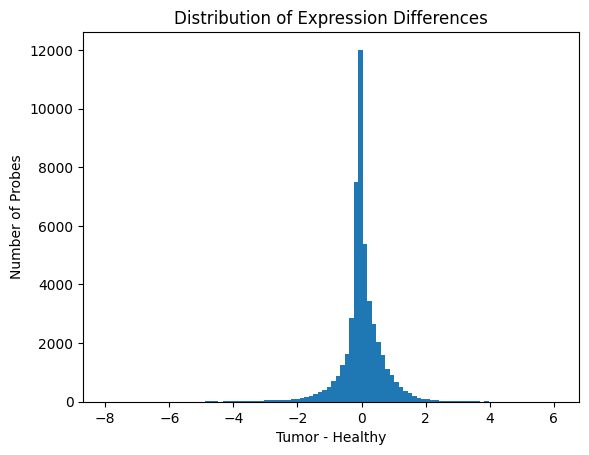

In [13]:
import matplotlib.pyplot as plt

plt.hist(
    df["tumor_minus_healthy"],
    bins=100
)

plt.xlabel("Tumor - Healthy")
plt.ylabel("Number of Probes")
plt.title("Distribution of Expression Differences")

plt.show()

In [14]:
top_down = df.sort_values(
    "tumor_minus_healthy",
    ascending=True
)

top_down[[
    "ID_REF",
    "healthy_mean",
    "tumor_mean",
    "tumor_minus_healthy"
]].head(20)

,ID_REF,healthy_mean,tumor_mean,tumor_minus_healthy
14483,11729583_x_at,12.568558,4.582909,-7.985649
11664,11726764_at,11.404280,3.807132,-7.597148
13671,11728771_a_at,12.401594,4.890284,-7.511310
14482,11729582_s_at,11.052652,3.803621,-7.249031
22194,11737294_a_at,10.276762,3.137554,-7.139208
17738,11732838_at,10.877106,3.747131,-7.129975
18644,11733744_at,11.862336,5.079228,-6.783108
6959,11722059_at,12.954770,6.235244,-6.719526
9438,11724538_a_at,9.797320,3.355973,-6.441347
15873,11730973_a_at,11.028706,4.607981,-6.420725


In [15]:
top_up_50 = top_up.head(50)
top_down_50 = top_down.head(50)

print(top_up_50["ID_REF"].tolist())

['11718841_s_at', '11744030_a_at', '11744031_at', '11758028_s_at', '11728232_a_at', '11735833_a_at', '11723635_s_at', '11722783_at', '11719366_s_at', '11728234_a_at', '11746506_a_at', '11720372_at', '11725749_a_at', '11756074_a_at', '11744424_a_at', '11742711_at', '11715493_a_at', '11728477_at', '11721305_a_at', '11756343_a_at', '11725765_a_at', '11715350_a_at', '11754604_x_at', '11725766_x_at', '11716665_s_at', '11744718_a_at', '11727790_x_at', '11733707_x_at', '11715352_x_at', '11757018_a_at', '11716663_a_at', '11754026_a_at', '11743240_a_at', '11757941_s_at', '11728984_a_at', '11743856_a_at', '11755928_s_at', '11715351_at', '11751904_x_at', '11752940_a_at', '11716664_x_at', '11755730_x_at', '11745361_a_at', '11757736_s_at', '11742938_at', '11733706_s_at', '11734548_a_at', '11763828_a_at', '11756316_a_at', '11741897_a_at']


In [16]:
print(top_down_50["ID_REF"].tolist())

['11729583_x_at', '11726764_at', '11728771_a_at', '11729582_s_at', '11737294_a_at', '11732838_at', '11733744_at', '11722059_at', '11724538_a_at', '11730973_a_at', '11731957_at', '11717820_a_at', '11730779_at', '11728746_a_at', '11730780_x_at', '11751355_a_at', '11723027_at', '11730765_at', '11746965_a_at', '11733115_a_at', '11728726_a_at', '11753653_a_at', '11722994_s_at', '11723899_a_at', '11755975_x_at', '11727553_a_at', '11759415_at', '11732699_a_at', '11729538_at', '11744099_a_at', '11732700_x_at', '11717127_a_at', '11725226_at', '11727554_s_at', '11715228_s_at', '11724847_a_at', '11723302_a_at', '11724490_x_at', '11723826_a_at', '11724488_at', '11759464_at', '11750517_x_at', '11748513_x_at', '11743657_x_at', '11720105_a_at', '11742378_a_at', '11743655_a_at', '11724489_s_at', '11743656_a_at', '11741499_x_at']


I want to see whether the strongest hits look like:

Healthy	| Adjacent | Tumor

---2----------5--------9---

or

Healthy |	Adjacent	| Tumor

---2----------2--------9---

In [17]:
top_up[[
    "healthy_mean",
    "adjacent_mean",
    "tumor_mean",
    "tumor_minus_healthy"
]].head(10)

,healthy_mean,adjacent_mean,tumor_mean,tumor_minus_healthy
3741,3.774622,5.646451,9.864659,6.090037
28930,1.976232,2.081974,7.637574,5.661342
28931,2.030672,2.121774,7.238808,5.208136
42928,4.137704,3.537792,9.197886,5.060182
13132,3.926806,3.990905,8.911113,4.984307
20733,3.298220,3.507156,8.206537,4.908317
8535,3.187314,3.545078,7.814478,4.627164
7683,2.393404,2.224967,6.901970,4.508566
4266,5.280750,6.649669,9.749552,4.468802
13134,3.029944,3.181895,7.406224,4.376280


Notice something?

There are at least two different patterns
Pattern A: Progressive increase

Example:

Healthy	Adjacent	Tumor
3.77	5.65	9.86

Healthy → Adjacent → Tumor

This is exactly the kind of thing we were hoping to find.

Something is already changing in tissue near the tumor.

Pattern B: Tumor-specific activation

Example:

Healthy	Adjacent	Tumor
1.98	2.08	7.64

Healthy ≈ Adjacent

Then BOOM.

Tumor.

This suggests the gene is primarily associated with the cancer itself rather than changes in surrounding tissue.

#I'd create three categories

For every probe:

Category 1

Progressive increase

Healthy < Adjacent < Tumor
Category 2

Progressive decrease

Healthy > Adjacent > Tumor
Category 3

Tumor-specific

Healthy ≈ Adjacent
Tumor very different

# Differential Expression Results

Dataset:
GSE44076

Groups:
- Healthy (n=50)
- Adjacent Normal (n=98)
- Tumor (n=98)

Analysis:
Computed mean expression for each group and ranked probes by tumor minus healthy expression.

Key observation:
Most probes cluster around zero difference, while a subset exhibit substantial positive or negative changes.

In [18]:
df["healthy_to_adjacent"] = (
    df["adjacent_mean"] - df["healthy_mean"]
)

df["adjacent_to_tumor"] = (
    df["tumor_mean"] - df["adjacent_mean"]
)

In [19]:
df[[
    "ID_REF",
    "healthy_to_adjacent",
    "adjacent_to_tumor"
]].head()

,ID_REF,healthy_to_adjacent,adjacent_to_tumor
0,11715100_at,-0.052440,0.344551
1,11715101_s_at,-0.345861,0.371743
2,11715102_x_at,-0.125081,0.354738
3,11715103_x_at,0.195816,0.121944
4,11715104_s_at,0.152302,-3.985516


In [22]:
df["progression_strength"] = (
    df["healthy_to_adjacent"]
    +
    df["adjacent_to_tumor"]
)

In [23]:
progressive = df[
    (df["healthy_to_adjacent"] > 1)
    &
    (df["adjacent_to_tumor"] > 1)
]

progressive.sort_values(
    "progression_strength",
    ascending=False
).head(20)

,ID_REF,GSM1077598,GSM1077599,GSM1077600,GSM1077601,GSM1077602,GSM1077603,GSM1077604,GSM1077605,GSM1077606,...,GSM1077842,GSM1077843,healthy_mean,adjacent_mean,tumor_mean,tumor_minus_healthy,progression_score,healthy_to_adjacent,adjacent_to_tumor,progression_strength
3741,11718841_s_at,3.2438,2.4622,4.1106,3.2948,5.4682,3.5043,3.2685,2.4047,3.4674,...,12.7360,9.9439,3.774622,5.646451,9.864659,6.090037,6.090037,1.871829,4.218208,6.090037
4266,11719366_s_at,6.0724,4.3096,6.1903,6.4009,5.8293,4.7931,4.6921,3.6047,4.4289,...,10.8866,9.7741,5.280750,6.649669,9.749552,4.468802,4.468802,1.368919,3.099883,4.468802
31406,11746506_a_at,2.6231,2.0680,2.3849,2.5248,2.8456,2.3358,2.7988,2.6746,2.9582,...,11.4772,3.1773,2.469930,4.140550,6.840701,4.370771,4.370771,1.670620,2.700151,4.370771
27611,11742711_at,2.5476,2.5294,2.8616,2.7690,2.2009,2.4976,2.9660,2.2587,2.8185,...,7.6637,4.2374,2.551238,4.956176,6.780512,4.229274,4.229274,2.404938,1.824337,4.229274
6205,11721305_a_at,4.0885,4.6776,4.5345,4.7008,4.9612,3.5509,3.1516,3.9851,4.5957,...,7.2782,8.2223,4.354818,5.369066,8.508893,4.154075,4.154075,1.014248,3.139827,4.154075
250,11715350_a_at,3.8254,3.8426,5.8398,4.5819,4.7999,4.1605,4.3699,5.0634,5.0718,...,8.7035,6.5085,4.463706,6.092519,8.519265,4.055559,4.055559,1.628813,2.426746,4.055559
39504,11754604_x_at,2.8230,2.7844,2.9975,3.6180,2.9998,3.6990,3.8174,3.8931,3.6302,...,11.7996,3.9559,3.435746,4.971268,7.473628,4.037882,4.037882,1.535522,2.502359,4.037882
12690,11727790_x_at,3.9625,3.4337,4.7088,4.9346,4.5117,5.0000,5.2735,4.7263,4.9684,...,11.9738,5.1431,4.522104,6.118035,8.481600,3.959496,3.959496,1.595931,2.363565,3.959496
41918,11757018_a_at,5.8629,5.2701,6.2254,4.4935,6.0243,4.7761,5.5476,5.4025,5.2730,...,9.3229,8.0955,5.694566,7.803164,9.579678,3.885112,3.885112,2.108598,1.776513,3.885112
42841,11757941_s_at,3.5459,3.6960,3.8860,3.4821,3.3001,3.6821,3.9537,4.2207,3.6861,...,8.0825,5.0519,3.566546,5.638893,7.427850,3.861304,3.861304,2.072347,1.788957,3.861304


Quick bioinformatics note

Notice something interesting:

Since

healthy_to_adjacent =
adjacent_mean - healthy_mean

and

adjacent_to_tumor =
tumor_mean - adjacent_mean

adding them gives:

tumor_mean - healthy_mean

The adjacent terms cancel.

Mathematically:

(adjacent−healthy)+(tumor−adjacent)=tumor−healthy

So the progression_strength is just the total change.

The reason we created it isn't because it's new information.

It's because we're filtering for genes where both steps are positive.

That gives us:

Healthy < Adjacent < Tumor

instead of merely:

Healthy < Tumor

which is a much stronger biological story.

Is this gene already known in colorectal cancer?

Is this gene involved in inflammation?

Cell division?

WNT signaling?

Tumor invasion?

In [24]:
# Get top 20 progressive probes
top_progressive = progressive.sort_values(
    "progression_strength",
    ascending=False
).head(20)

top_progressive_ids = top_progressive["ID_REF"].tolist()
top_progressive_ids

['11718841_s_at',
 '11719366_s_at',
 '11746506_a_at',
 '11742711_at',
 '11721305_a_at',
 '11715350_a_at',
 '11754604_x_at',
 '11727790_x_at',
 '11757018_a_at',
 '11757941_s_at',
 '11755730_x_at',
 '11757736_s_at',
 '11728809_a_at',
 '11737944_x_at',
 '11746872_a_at',
 '11721307_at',
 '11715359_a_at',
 '11744128_x_at',
 '11715360_x_at',
 '11715353_s_at']

Uploading GPL13667-15572.txt

Full table from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL13667

Platform GPL13667		Query DataSets for GPL13667
Status	Public on May 31, 2011
Title	[HG-U219] Affymetrix Human Genome U219 Array
Technology type	in situ oligonucleotide
Distribution	commercial
Organism	Homo sapiens
Manufacturer	Affymetrix
Manufacture protocol	see manufacturer's website


Submission date	May 31, 2011
Last update date	Mar 21, 2019
Organization	Affymetrix, Inc.
E-mail(s)	geo@ncbi.nlm.nih.gov, support@affymetrix.com
Phone	888-362-2447
URL	http://www.affymetrix.com/index.affx
Street address
City	Santa Clara
State/province	CA
ZIP/Postal code	95051
Country	USA


In [26]:
annotation = pd.read_csv(
    "/GPL13667-15572.txt",
    sep="\t",
    skiprows=43
)

print(annotation.shape)
print(annotation.columns)
annotation.head()

(49386, 43)
Index(['ID', 'GeneChip Array', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Transcript ID(Array Design)',
       'Target Description', 'Representative Public ID',
       'Archival UniGene Cluster', 'UniGene ID', 'Genome Version',
       'Alignments', 'Gene Title', 'Gene Symbol', 'Chromosomal Location',
       'GB_LIST', 'SPOT_ID', 'Unigene Cluster Type', 'Ensembl', 'Entrez Gene',
       'SwissProt', 'EC', 'OMIM', 'RefSeq Protein ID', 'RefSeq Transcript ID',
       'FlyBase', 'AGI', 'WormBase', 'MGI Name', 'RGD Name',
       'SGD accession number', 'Gene Ontology Biological Process',
       'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function',
       'Pathway', 'InterPro', 'Trans Membrane', 'QTL',
       'Annotation Description', 'Annotation Transcript Cluster',
       'Transcript Assignments', 'Annotation Notes'],
      dtype='object')


/tmp/ipykernel_664/395325212.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  annotation = pd.read_csv(


,ID,GeneChip Array,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Transcript ID(Array Design),Target Description,Representative Public ID,Archival UniGene Cluster,...,Gene Ontology Cellular Component,Gene Ontology Molecular Function,Pathway,InterPro,Trans Membrane,QTL,Annotation Description,Annotation Transcript Cluster,Transcript Assignments,Annotation Notes
0,11715100_at,Human Genome HG-U219 Array,Homo sapiens,20-Aug-10,Consensus sequence,Affymetrix Proprietary Database,g21264570,g21264570 /TID=g21264570 /CNT=1 /FEA=FLmRNA /T...,g21264570,---,...,0000786 // nucleosome // inferred from electro...,0003677 // DNA binding // inferred from electr...,---,---,---,---,This probe set was annotated using the Matchin...,NM_003534(11),"NM_003534 // Homo sapiens histone cluster 1, H...",BC079835 // gb_htc // 6 // Cross Hyb Matching ...
1,11715101_s_at,Human Genome HG-U219 Array,Homo sapiens,20-Aug-10,Consensus sequence,Affymetrix Proprietary Database,g21264570,g21264570 /TID=g21264570 /CNT=1 /FEA=FLmRNA /T...,g21264570,---,...,0000786 // nucleosome // inferred from electro...,0003677 // DNA binding // inferred from electr...,---,---,---,---,This probe set was annotated using the Matchin...,"BC079835(11),NM_003534(11)","BC079835 // Homo sapiens histone cluster 1, H3...",---
2,11715102_x_at,Human Genome HG-U219 Array,Homo sapiens,20-Aug-10,Consensus sequence,Affymetrix Proprietary Database,g21264570,g21264570 /TID=g21264570 /CNT=1 /FEA=FLmRNA /T...,g21264570,---,...,0000786 // nucleosome // inferred from electro...,0003677 // DNA binding // inferred from electr...,---,---,---,---,This probe set was annotated using the Matchin...,NM_003534(11),"NM_003534 // Homo sapiens histone cluster 1, H...",GENSCAN00000044911 // ensembl // 4 // Cross Hy...
3,11715103_x_at,Human Genome HG-U219 Array,Homo sapiens,20-Aug-10,Consensus sequence,Affymetrix Proprietary Database,g22748780,g22748780 /TID=g22748780 /CNT=1 /FEA=FLmRNA /T...,g22748780,---,...,---,---,---,---,---,---,This probe set was annotated using the Matchin...,"BC017672(11),BC044250(9),ENST00000327473(11),N...",BC017672 // Homo sapiens tumor necrosis factor...,---
4,11715104_s_at,Human Genome HG-U219 Array,Homo sapiens,20-Aug-10,Consensus sequence,Affymetrix Proprietary Database,g30039713,g30039713 /TID=g30039713 /CNT=1 /FEA=FLmRNA /T...,g30039713,---,...,0016020 // membrane // inferred from electroni...,---,---,IPR004878 // Protein of unknown function DUF27...,"NP_835454.1 // span:30-52,62-81,101-120,135-15...",---,This probe set was annotated using the Matchin...,"ENST00000331427(11),ENST00000426069(11),NM_178...",ENST00000331427 // cdna:known chromosome:GRCh3...,GENSCAN00000031612 // ensembl // 8 // Cross Hy...


This is for merging the "random" looking names like "11715104_s_at" into something more legible for us. Rather than simple probe names.

In [27]:
annotation_small = annotation[["ID", "Gene Symbol", "Gene Title"]]

annotated = top_progressive.merge(
    annotation_small,
    left_on="ID_REF",
    right_on="ID",
    how="left"
)

annotated[[
    "ID_REF",
    "Gene Symbol",
    "Gene Title",
    "healthy_mean",
    "adjacent_mean",
    "tumor_mean",
    "healthy_to_adjacent",
    "adjacent_to_tumor",
    "progression_strength"
]]

,ID_REF,Gene Symbol,Gene Title,healthy_mean,adjacent_mean,tumor_mean,healthy_to_adjacent,adjacent_to_tumor,progression_strength
0,11718841_s_at,IL8,interleukin 8,3.774622,5.646451,9.864659,1.871829,4.218208,6.090037
1,11719366_s_at,CXCL1,chemokine (C-X-C motif) ligand 1 (melanoma gro...,5.280750,6.649669,9.749552,1.368919,3.099883,4.468802
2,11746506_a_at,SPP1,secreted phosphoprotein 1,2.469930,4.140550,6.840701,1.670620,2.700151,4.370771
3,11742711_at,THBS2,thrombospondin 2,2.551238,4.956176,6.780512,2.404938,1.824337,4.229274
4,11721305_a_at,PHLDA1,"pleckstrin homology-like domain, family A, mem...",4.354818,5.369066,8.508893,1.014248,3.139827,4.154075
5,11715350_a_at,COL1A1,"collagen, type I, alpha 1",4.463706,6.092519,8.519265,1.628813,2.426746,4.055559
6,11754604_x_at,SPP1,secreted phosphoprotein 1,3.435746,4.971268,7.473628,1.535522,2.502359,4.037882
7,11727790_x_at,SPP1,secreted phosphoprotein 1,4.522104,6.118035,8.481600,1.595931,2.363565,3.959496
8,11757018_a_at,COL12A1,"collagen, type XII, alpha 1",5.694566,7.803164,9.579678,2.108598,1.776513,3.885112
9,11757941_s_at,THBS2,thrombospondin 2,3.566546,5.638893,7.427850,2.072347,1.788957,3.861304


Clean table now:

In [28]:
clean_annotated = annotated[[
    "Gene Symbol",
    "Gene Title",
    "ID_REF",
    "healthy_mean",
    "adjacent_mean",
    "tumor_mean",
    "healthy_to_adjacent",
    "adjacent_to_tumor",
    "progression_strength"
]].drop_duplicates(subset=["Gene Symbol"])

clean_annotated

,Gene Symbol,Gene Title,ID_REF,healthy_mean,adjacent_mean,tumor_mean,healthy_to_adjacent,adjacent_to_tumor,progression_strength
0,IL8,interleukin 8,11718841_s_at,3.774622,5.646451,9.864659,1.871829,4.218208,6.090037
1,CXCL1,chemokine (C-X-C motif) ligand 1 (melanoma gro...,11719366_s_at,5.280750,6.649669,9.749552,1.368919,3.099883,4.468802
2,SPP1,secreted phosphoprotein 1,11746506_a_at,2.469930,4.140550,6.840701,1.670620,2.700151,4.370771
3,THBS2,thrombospondin 2,11742711_at,2.551238,4.956176,6.780512,2.404938,1.824337,4.229274
4,PHLDA1,"pleckstrin homology-like domain, family A, mem...",11721305_a_at,4.354818,5.369066,8.508893,1.014248,3.139827,4.154075
5,COL1A1,"collagen, type I, alpha 1",11715350_a_at,4.463706,6.092519,8.519265,1.628813,2.426746,4.055559
8,COL12A1,"collagen, type XII, alpha 1",11757018_a_at,5.694566,7.803164,9.579678,2.108598,1.776513,3.885112
11,APCDD1,adenomatosis polyposis coli down-regulated 1,11757736_s_at,4.352846,6.109643,8.042935,1.756797,1.933292,3.690089
12,COL8A1,"collagen, type VIII, alpha 1",11728809_a_at,3.202264,5.190180,6.813181,1.987916,1.623001,3.610917
16,TIMP1,TIMP metallopeptidase inhibitor 1,11715359_a_at,6.235950,7.588388,9.755856,1.352438,2.167468,3.519906


In [29]:
clean_annotated.to_csv("top_progressive_genes.csv", index=False)

#Pattern?

| Gene    | Progression Strength |
| ------- | -------------------: |
| IL8     |                 6.09 |
| CXCL1   |                 4.47 |
| SPP1    |                 4.37 |
| THBS2   |                 4.23 |
| PHLDA1  |                 4.15 |
| COL1A1  |                 4.06 |
| COL12A1 |                 3.89 |
| APCDD1  |                 3.69 |
| COL8A1  |                 3.61 |
| TIMP1   |                 3.52 |
| CXCL2   |                 3.47 |
| COL1A2  |                 3.44 |


## Preliminary Findings

The strongest progressively increasing genes were enriched for inflammatory signaling and extracellular matrix remodeling functions.

Notable genes included IL8, CXCL1, CXCL2, SPP1, THBS2, TIMP1, and several collagen genes (COL1A1, COL1A2, COL8A1, COL12A1).

Many of these genes showed increased expression in adjacent normal tissue relative to healthy tissue and further increased expression in tumor tissue, suggesting molecular alterations may occur prior to overt tumor formation.